<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:orange; font-size:36px;">A Deep Learning and Big Data Approach for Predictive Customer Targeting in Bank Marketing Campaigns</h1>

<b>Author:</b> J.A Montuya<br />
<b>Student ID:</b> 2025040<br />
<h3>Abstract:</h3>
    Marketing campaigns are essential business strategies that build brand awareness and drive revenue growth, however, inefficient customer targeting can lead to wasted resources and poor customer engagement, resulting in large financial losses. Thus, this study develops a predictive customer targeting system for bank marketing campaigns by leveraging Hadoop Distributed File System (HDFS) and Artificial Neural Network (ANN). The USCI’s bank marketing dataset was utilized, and an improvised sampling strategy was applied to address severe class imbalance, achieving a balanced F1 score of more than 80% for both classes. The ANN achieved 82.1% accuracy and was then benchmarked against Decision Tree, Random Forest, Logistic Regression, and CatBoost. Even though Random Forest achieved the highest performance score of 82.6%, this marginal difference still resulted in ANN being selected for its effectiveness in large-scale datasets and scalability in distributed computing environments. The trained model was deployed using the FastAPI framework, which created a production-ready microservice providing real-time prediction using the API endpoints. Results demonstrate that leveraging distributed file systems and deep learning models provides a practical and scalable solution for predictive customer targeting in marketing campaigns for the banking sector.

In [35]:
#Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Install Packages
#!python3 -m pip install imblearn hdfs --break-system-packages
#!python3 -m pip install catboost --break-system-packages
#!pip install catboost


## Import Libraries

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import json
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
#from pyspark.sql.types import *
#from pyspark.sql import functions
from imblearn.over_sampling import SMOTE
from sklearn import metrics
#from hdfs import InsecureClient

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

## Custom Functions

In [41]:
# Save model locally and upload to HDFS
def save_model(model, scaler, filename):
    hdfs_path = f'/marketing_campaign/models/{filename}.h5'
    
    print('----Exporting model locally.')
    try:
        # Save model locally
        model.save(f'{filename}.h5')
        
        # Save scaler and encoder
        print('----Exporting scaler')
        joblib.dump(scaler, 'scaler.pkl')
    
        print(f'Model was saved locally as {filename}.h5')
    except Exception as e:
        print('Failed to export the model.')
        print('Error details:', e)
        
    
    # Upload file to HDFS
    try:
        client = InsecureClient('http://localhost:9870', user='hduser')
        print('----Uploading model to HDFS.')
        with open(f'{filename}.h5', 'rb') as f:
            client.write(hdfs_path, f, overwrite=True)
        print('----Uploading scaler to HDFS.')
       
        with open('scaler.pkl', 'rb') as a:
            client.write(f'/marketing_campaign/models/scaler.pkl', a, overwrite=True)

        print(f"Model saved to HDFS at {hdfs_path}")
    except Exception as e:
        print('Failed to upload model to HDFS.')
        print('Error details:', e)


# This function will initialize model training
# X - independent variables
# y - target variables
# model - dictionary of models to be used
# param_grid - corresponding parameter grid per model
# split_size - train, test split size with 20% default
# cv - number of folds
def init_training(X_train, y_train, X_test, y_test, model, param_grid, split_size=0.20, cv=3, print_results=True):

    # Create variables to store model and results
    results=[]
    trained_models={}

    #Loop through each model
    for name, clf in models.items():
        print(clf, name)
        grid_search = GridSearchCV(clf, param_grid[name], cv=cv, scoring='accuracy')

        # Fit the grid search
        grid_search.fit(X_train, y_train)
        
        # Best parameters and best score
        best_params = grid_search.best_params_
        best_score = grid_search.best_score_
        
        # Get best model on the training data
        best_model = grid_search.best_estimator_

        # Predict Values
        X_pred = best_model.predict(X_train)
        y_pred = best_model.predict(X_test)
        
        # Store the Accuracy and F1
        train_acc = accuracy_score(y_train, X_pred)
        test_acc = accuracy_score(y_test, y_pred)
        
        train_f1 = f1_score(y_train, X_pred, average="weighted") 
        test_f1 = f1_score(y_test, y_pred, average="weighted")


        # Consolidate results
        results.append({'Model':name,
                    'Accuracy': test_acc,
                    'F1':test_f1,
                   })

        # Store best model
        trained_models[name]= best_model
        
        # Display the training and test score
        if print_results==True: 
            print(f'Model: {name}:')
            print(f'Best Params:{best_params}')
            print(f'Accuracy score for train:{train_acc: .4f}, test:{test_acc: .4f}.')
            print(f'F1 score for train: {train_f1:.4f}, test F1: {test_f1:.4f}')
            print('\n')
            print(classification_report(y_test, y_pred))
        else:
            pass

    # Return model training results and trained_models to be used for predictions
    return results, trained_models

# This function displays a performance comparison across all trained models
def gen_model_training_summary(result,title=''):
    # Convert to DataFrame and sort by R2 score
    results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=True)
    
    # Create subplots
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot Accuracy Score
    sns.barplot(ax=ax[0], x=results_df.Model, y=results_df.Accuracy, palette="Blues")
    ax[0].set_title("Accuracy Score Comparison")
    ax[0].set_ylabel("Accuracy Score")
    ax[0].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Plot MAE
    sns.barplot(ax=ax[1], x=results_df.Model, y=results_df.F1, palette="Greens")
    ax[1].set_title("F1 Score Comparison")
    ax[1].set_ylabel("F1 Score")
    ax[1].set_xticklabels(results_df.Model, rotation=20, ha="right")
    
    # Adjust layout and show plot
    plt.suptitle(title)
    plt.tight_layout()
        # Export Graph
    export_graph('TMLM_results', 'plt', plt)
    
    plt.show()

# Simplify Exporting of Graphs
def export_graph(filename='img', graph_type='plt', plt=plt):
    try:
        if graph_type == 'fig':
            fig.write_image(f"./assets/{filename}.png")
        else:
            plt.savefig(f"./assets/{filename}.png", dpi=300, bbox_inches='tight')
        print('Graph exported.')
    except Exception as e:
        print('There is a error exporting the graph.')
        print('Error Details:', e)



# Define text sizes for plt graphs
plt.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})


## Import Dataset from HDFS

In [44]:
# Importing dataset from HDFS using Spark API
df = spark.read.load('hdfs://localhost:9000/marketing_campaign/train_data/marketing_data.csv', format="csv", header="true")
df.printSchema()

NameError: name 'spark' is not defined

In [46]:
# Convert data into a Pandas Dataframe 
#campaign_data=df.toPandas()

# Local file read/upload approach
campaign_data=pd.read_csv('marketing_data.csv')

campaign_data.head()

,Unnamed: 0,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,target
0,0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


<br />
<center><h2>Data Preparation</h2></center>
<br />

In [48]:
# Analyze information of the data frame
campaign_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   45211 non-null  int64 
 1   age          45211 non-null  int64 
 2   job          44923 non-null  object
 3   marital      45211 non-null  object
 4   education    43354 non-null  object
 5   default      45211 non-null  object
 6   balance      45211 non-null  int64 
 7   housing      45211 non-null  object
 8   loan         45211 non-null  object
 9   contact      32191 non-null  object
 10  day_of_week  45211 non-null  int64 
 11  month        45211 non-null  object
 12  duration     45211 non-null  int64 
 13  campaign     45211 non-null  int64 
 14  pdays        45211 non-null  int64 
 15  previous     45211 non-null  int64 
 16  poutcome     8252 non-null   object
 17  target       45211 non-null  object
dtypes: int64(8), object(10)
memory usage: 6.2+ MB


        By extracting information from the dataframe, 45,211 records and 18 columns were identified. The dataset contains variables in both int64 and object formats. However, inconsistencies were observed in the Non-Null Count column; for example, the contact feature has only 32,191 records, indicating the presence of missing or null values in the dataset.

In [52]:
campaign_data.describe()

,Unnamed: 0,age,balance,day_of_week,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22605.000000,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,13051.435847,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,0.000000,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,11302.500000,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,22605.000000,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,33907.500000,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,45210.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### Null Checking

    Null checking was applied to the dataset to avoid errors during training. This process also improves model accuracy, as missing or null values lead to an inconsistent pattern or noise.

    As depicted in the graph below, the contact and poutcome features have a large percentage of missing data, 30% and 80% respectively. This should be addressed to improve the model's performance and prevent errors in succeeding steps for training the model.


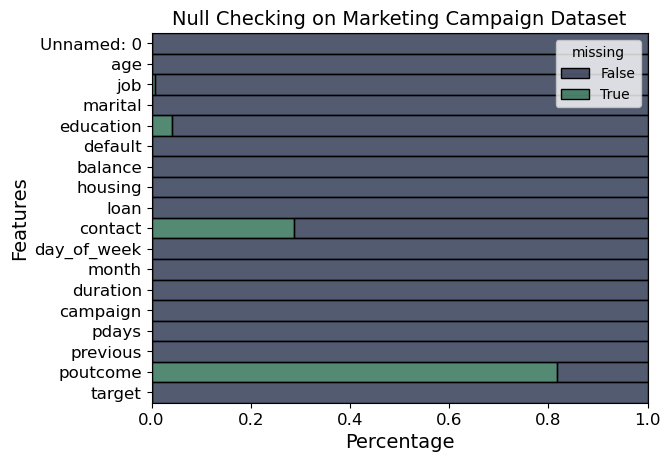

In [55]:
sns.set_palette('cubehelix')

sns.histplot(data=campaign_data.isnull().melt(value_name='missing'),
           y='variable',
           hue='missing',
           multiple='fill')

plt.title('Null Checking on Marketing Campaign Dataset')
plt.xlabel('Percentage')
plt.ylabel('Features')

plt.show()

#### Check for Duplicates

In [57]:
print(f'Number of duplicates in the dataframe: {campaign_data.duplicated().sum()}.')

Number of duplicates in the dataframe: 0.


#### Check for unique values
    
    Examining the number of unique values helps determine whether a feature is categorical or numerical, and then we apply proper encoding methods to the dataframe.

In [59]:
# Check for unique 
campaign_data.nunique()

Unnamed: 0     45211
age               77
job               11
marital            3
education          3
default            2
balance         7168
housing            2
loan               2
contact            2
day_of_week       31
month             12
duration        1573
campaign          48
pdays            559
previous          41
poutcome           3
target             2
dtype: int64

<br />
<b>Convert features from Objects to Numeric

In [64]:
cols = ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
campaign_data[cols] = campaign_data[cols].apply(pd.to_numeric, errors='coerce')

<br />
<b>Delete Unusable Features and Records with Null Values

In [67]:
# Drop unusable features and separate data into dependent and independent variables
# Drop records containing null values
# try catch was implemented to avoid errors when rerunning the patch of code
try:
    df=campaign_data.copy()
    df.drop(columns=['Unnamed: 0','poutcome','pdays','day_of_week','month','contact'], inplace=True) 
    #df.drop(columns=['_c0','poutcome','pdays', 'day_of_week','month'], inplace=True)    
    df.dropna(axis=0, inplace=True)
    y = df['target']
    X = df.drop(columns=['target'])
except Exception as e:
    print('No changes made in the dataset.')
    print(f'Exception:{e}')

X.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
duration     0
campaign     0
previous     0
dtype: int64

<br />
<center><h2>Data Visualisation</h2></center>
<br />

### Projecting Marketing Campaign Acceptance by Age Group

    Through the projection of the number of acceptances by age groups, we can gather insights into which segments are most likely to avail products or services being offered and guide business decisions, such as prioritizing customers within that age group with the highest acceptance rate. 

    Results show an increase in campaign acceptance among individuals aged 18 - 29, peaking at ages 30-34, and an observable decline in older age groups. This gives the business insight to prioritize people aged 25-39, as they have a higher chance of accepting the campaign.

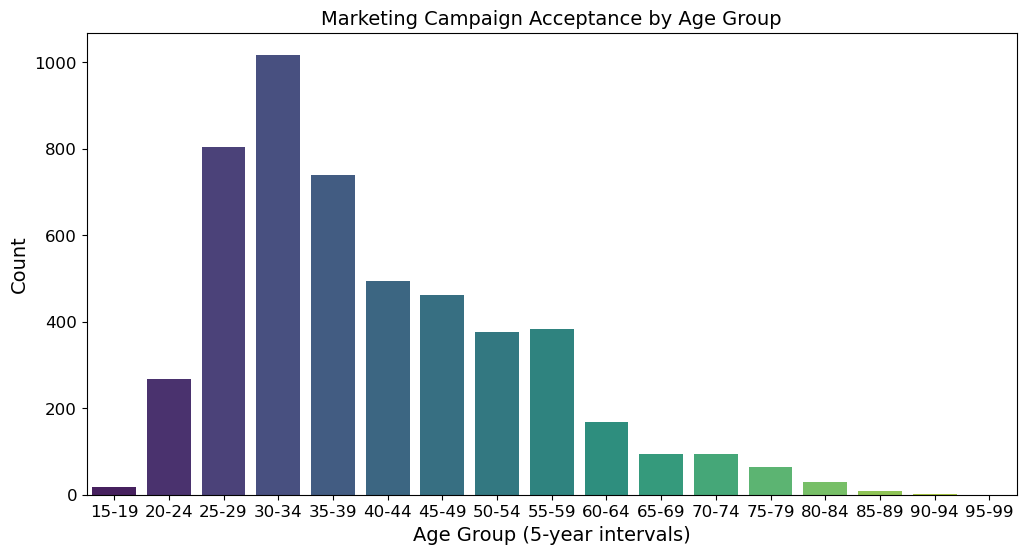

In [71]:
# Filtering customers who accepted the campaign 
df_yes = df[df['target'] == 'yes'].copy() 

# Visualisation of campaign acceptance by age group
min_age = df_yes['age'].min() // 5 * 5
max_age = (df_yes['age'].max() // 5 + 1) * 5
bins = range(min_age, max_age + 1, 5)
labels = [f"{b}-{b+4}" for b in bins[:-1]]

df_yes['age_group'] = pd.cut(df_yes['age'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(12, 6))
sns.countplot(x='age_group', data=df_yes, order=labels, palette='viridis')
plt.xlabel('Age Group (5-year intervals)')
plt.ylabel('Count')
plt.title('Marketing Campaign Acceptance by Age Group')
plt.show()


### Categorical Features Analysis


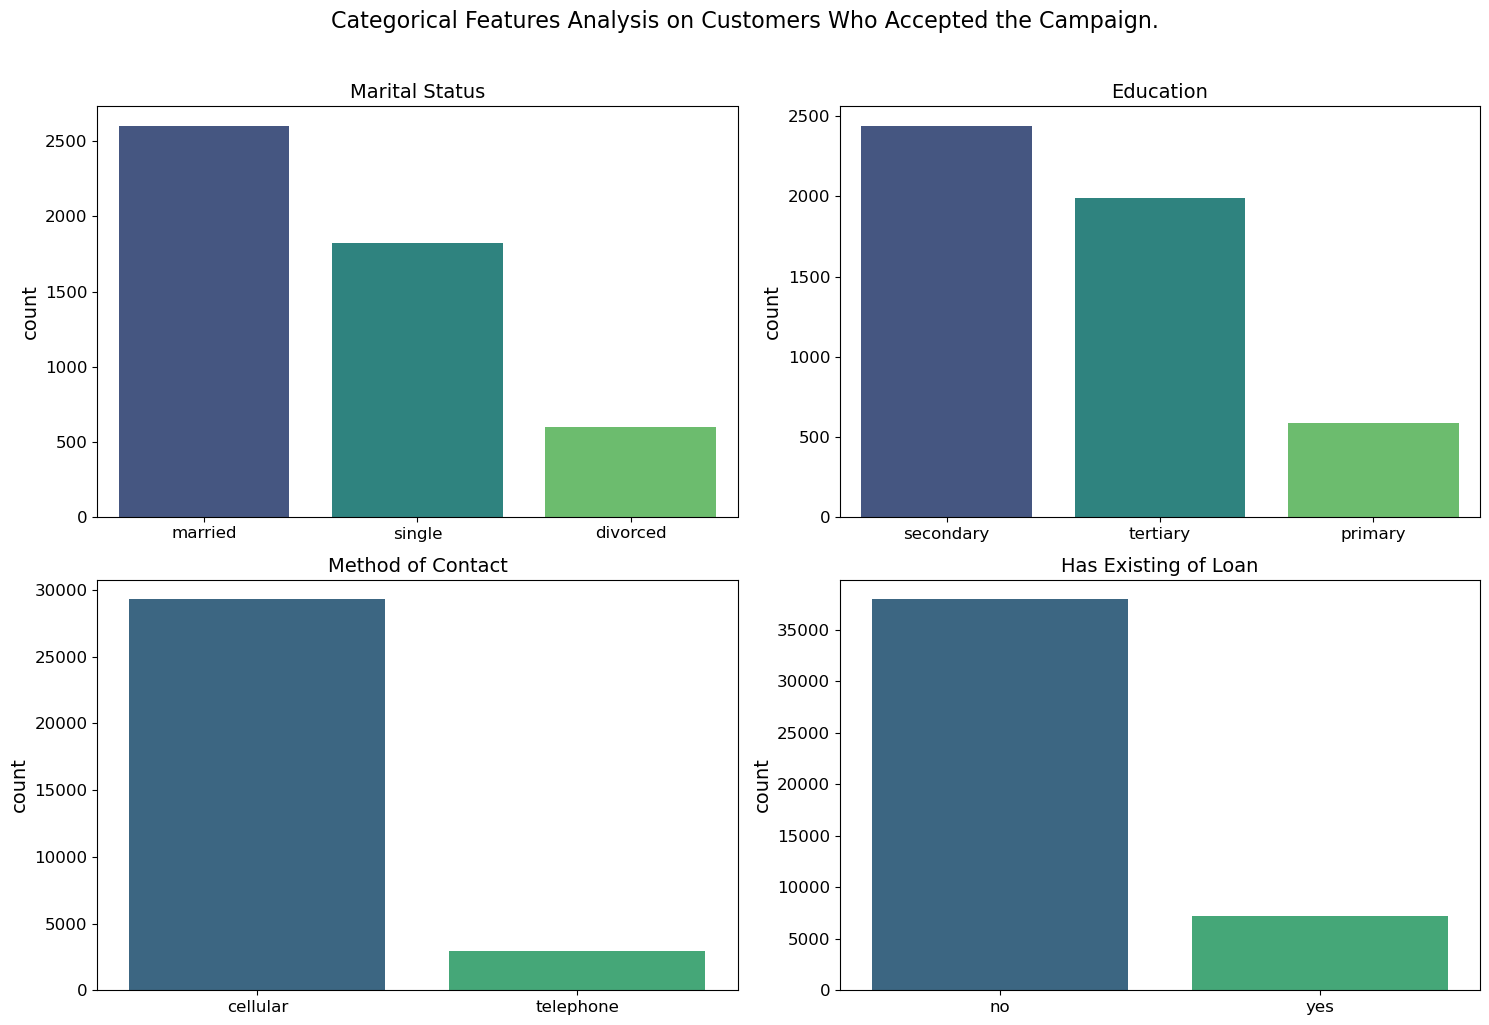

In [74]:
# Create subplots for Categorical Features Analysis
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs = axs.flatten() 

sns.countplot(x='marital', data=df_yes, palette='viridis', ax=axs[0],)
axs[0].set_title('Marital Status')
axs[0].set_xlabel('')

sns.countplot(x='education', data=df_yes, palette='viridis', ax=axs[1])
axs[1].set_title('Education')
axs[1].set_xlabel('')

sns.countplot(x='contact', data=campaign_data, palette='viridis', ax=axs[2])
axs[2].set_title('Method of Contact')
axs[2].set_xlabel('')

sns.countplot(x='loan', data=campaign_data, palette='viridis', ax=axs[3])
axs[3].set_title('Has Existing of Loan')
axs[3].set_xlabel('')

fig.suptitle('Categorical Features Analysis on Customers Who Accepted the Campaign.', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()


### Projecting Jobs with the Highest Campaign Acceptance Rate

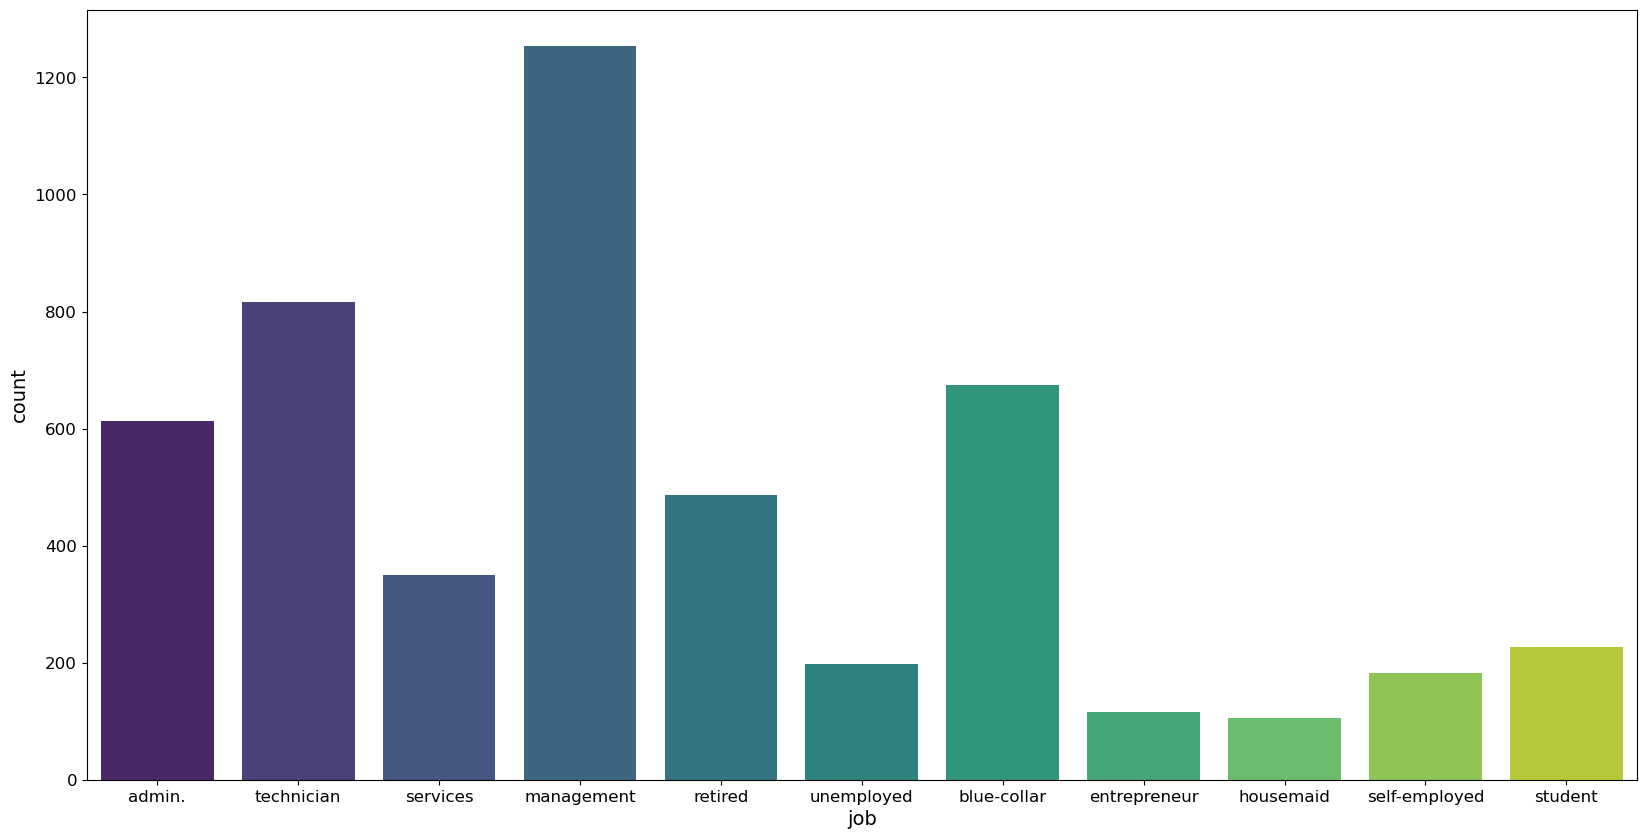

In [77]:
plt.figure(figsize=(20,10))
sns.countplot(x='job', data=df_yes, palette='viridis')
plt.show()

### Analysis on the Target Variable

    One observable issue is that there is a substantial class imbalance of the dependent variable in the dataset, as shown in the graph below. More people did not respond to the campaign than those who did. This imbalance can cause the model to be biased towards predicting the majority class and neglecting minority patterns, leading to a significant drop in precision and recall. Thus, SMOTE will be applied to assist with this issue.

Graph exported.


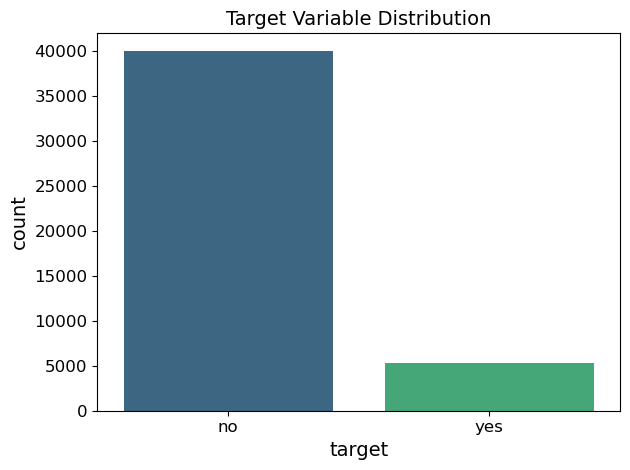

In [80]:
# Display target variable distribution using countplot
sns.countplot(x='target', data=campaign_data, palette='viridis')
plt.title('Target Variable Distribution')
plt.tight_layout()

export_graph('target_variable_distribution', 'plt')

plt.show()

<br />
<center><h2>Model Training</h2></center>
<br />

### Encode Values

In [83]:
# Convert Default Feature
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X[col] = X[col].map({'yes': 1, 'no': 0})

# Map target to 1 and 0
y=y.map({'yes': 1, 'no': 0})

# G
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
# One-Hot Encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'duration', 'campaign',
       'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_secondary', 'education_tertiary'],
      dtype='object')

### Solving Class Distribution Imbalance using SMOTE

In [85]:
# Split into train and test
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
 
# Apply SMOTE
smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=3)
X_train_res_smote, y_train_res_smote = smote.fit_resample(X_train_smote, y_train_smote)

pd.Series(y_train_res_smote).value_counts()

target
0    26720
1    13360
Name: count, dtype: int64

#### Testing SMOTE Approach using ANN

In [89]:
X_test_smote.shape, y_test_smote.shape

((12958, 22), (12958,))

In [ ]:
# Apply Scaling  
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_res_smote)
X_test_smote_scaled  = scaler.transform(X_test_smote)
print(X_train_smote_scaled.shape, X_test_smote_scaled.shape)


# ANN Model Training
model_smote = Sequential([
    Dense(64, input_dim=X_train_smote_scaled.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_smote.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_smote.fit(
    X_train_smote_scaled, y_train_res_smote,
    validation_split=0.2,
    epochs=50,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
loss, accuracy = model_smote.evaluate(X_train_smote_scaled, y_train_res_smote)
print(f"Train Accuracy: {accuracy*100:.2f}%")

y_pred_results = model_smote.predict(X_test_smote_scaled)
y_pred_results = [round(x[0]) for x in y_pred_results]

acc = accuracy_score(y_test_smote, y_pred_results)
f1  = f1_score(y_test_smote, y_pred_results, average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

print(classification_report(y_test_smote, y_pred_results))


        The results show that SMOTE was ineffective in handling class imbalance, based on the performance of the minority class "1", which achieved scores of 0.54 in precision, 0.38 in recall, and 0.44 in f1-score. This suggests that the model is having difficulty predicting the minority class and would perform poorly in deployment. Therefore, further approaches should be explored.

### Improvised Sampling Strategy to Handle Class Imbalance
    An improvised approach was implemented by determining the total number of records of Class Label 1  and randomly selecting an equal number of test data from Class Label 0 to avoid bias.



In [ ]:
# Create new dataframe
new_df = X
new_df['target']=y
count_1 = new_df[new_df['target'] == 1].shape[0]
count_0 = new_df[new_df['target'] == 0].shape[0]

# Get a random sample of class label 0, and it should be equal to the count of the minority class
df_0_sampled = new_df[new_df['target'] == 0].sample(n=count_1, random_state=42)

# Combine both classes
df_balanced = pd.concat([df_0_sampled, new_df[new_df['target'] == 1]], axis=0)

# Shuffle the resulting dataframe to avoid bias
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Original dataset shape:", df.shape)
print("Balanced dataset shape:", df_balanced.shape)
print('Class Distribution:\n ',df_balanced['target'].value_counts())
X = df_balanced.drop(columns=['target'])
y = df_balanced['target']

# Train Test Split at 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


    The improvised sampling strategy yielded an improved classification performance of Class Label 1, from around 50% using SMOTE to above 80%. The performance of both classes now has a comparable F1 score of around 80% to 83%, which suggests that the impact of class imbalance is substantially reduced.  Thus, this approach is preferred for this study.


#### Scale Data

In [ ]:
# Scale data using Standard Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled.shape, X_test_scaled.shape

#### Artificial Neural Network - Classification
The input and hidden layers utilize ReLU since it mitigates vanishing gradients and accelerates convergence, while the output layer uses a sigmoid activation to output probability for binary classification

In [ ]:
# Setup 1: This Setup returns Accuracy: 0.8151 and F1 Score: 0.8151
# model = Sequential([
#     Dense(64, input_dim=X_train.shape[1], activation='relu'), 
#     Dense(32, activation='relu'),  
#     Dense(1, activation='sigmoid')                             
# ])

#Setup 2: Accuracy: 0.8231 and F1 Score: 0.8230
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'), 
    Dropout(0.3),
    Dense(32, activation='relu'),  
    Dense(1, activation='sigmoid')                             
])

#Setup 3: Accuracy: 0.8188 and F1 Score: 0.8186
# model = Sequential([
#     Dense(128, input_dim=X_train.shape[1], activation='relu'), 
#     Dense(64, activation='relu'),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')                             
# ])

#Setup 4: Accuracy: 0.8218 and F1 Score: 0.8218
# model = Sequential([
#     Dense(256, input_dim=X_train.shape[1], activation='relu'), 
#     Dropout(0.3),
#     Dense(128, activation='relu'),
#     Dropout(0.3),
#     Dense(1, activation='sigmoid')                             
# ])

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy',  # binary classification
    metrics=['accuracy']
)


#### Implement Early Stopping to Avoid Overfitting. 
Early stopping halts training when validation performance stops improving based on patience and val_loss, preventing the model from memorizing the training set.

In [110]:

early_stop = EarlyStopping(
    monitor='val_loss',  
    patience=10,          
    restore_best_weights=True  
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=100,
    callbacks=[early_stop],
    verbose=1
)

NameError: name 'model' is not defined

In [32]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

NameError: name 'model' is not defined

In [ ]:
y_pred_results = model.predict(X_test_scaled)

y_pred_results = [round(x[0]) for x in y_pred_results]

# Compute accuracy and F1
acc = accuracy_score(y_test, y_pred_results)
f1  = f1_score(y_test, y_pred_results, average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")


print(classification_report(y_pred_results, y_test))

    Among the tested network architectures, setup 2 demonstrated the best performance against other configurations with a score of  82% for both accuracy and F1-score. Thus, this configuration will be employed and evaluated against other traditional machine learning models.


# Traditional Classification Models

In [ ]:
# Classification param grid
param_grid = {
    'Decision Tree': {
        'max_depth': [2, 4, 6],
        'random_state': [0]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10, 20],
        'random_state': [0],
    },
    'Logistic Regression': {
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
        'l1_ratio': [0.0, 0.5, 1.0],
        'C': [0.1, 1.0, 10],
        'max_iter': [2000]
    },
    'CatBoost': {
        'iterations': [100, 200],
        'learning_rate': [0.05, 0.1],
        'depth': [ 6, 8],
        'scale_pos_weight': [1, 2]   # imbalance handling
    }
}

# Classification models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=0)
}


In [ ]:
results, trad_models_results = init_training(X_train_scaled, y_train, X_test_scaled, y_test, model, param_grid, cv=3, print_results=True)

In [ ]:
results.append({
    'Model': 'ANN',
    'Accuracy': acc,
    'F1': f1
})

gen_model_training_summary(results)

<br />
<center><h2>Results and Discussion</h2></center>
<br />

    The Artificial Neural Networks have achieved 82.1% accuracy with the use of an improvised sampling strategy to address the severe class imbalance in the training data, resulting in a balanced F1-score of exceeding 80% for both classes. Even though Random Forest has outperformed ANN by a margin with an 82.6% accuracy, after reviewing other related literature, the ANN was still chosen for deployment as it is more effective, especially in its high scalability in distributed computing environments and effectiveness in handling large-scale datasets. 

#### Save and Upload Model to HDFS

In [ ]:
# Save the model using custom function
# This will be automatically uploaded to the HDFS
save_model(model, scaler, 'ann_model')

<br />
<center><h2>References</h2></center>
<br />

<b>GridSearchCV<b>

scikit-learn developers (2025) GridSearchCV, scikit-learn. Available at: https://scikit-learn/stable/modules/generated/sklearn.model_selection.GridSearchCV.html (Accessed: October 16, 2025).

Jain, A. (2023) All about ANNs and Dropout. Medium. Available at: https://medium.com/@abhishekjainindore24/all-about-anns-and-dropout-39099dbc9f7e (Accessed: 19 October 2025).

Jain, A. (2024) Early stopping in neural networks. Medium, 20 September. Available at: https://medium.com/@abhishekjainindore24/early-stopping-in-neural-networks-ab0705a83f4d (Accessed: 19 October 2025).

Analytics Vidhya (2020) Overcoming class imbalance using SMOTE techniques. Available at: https://www.analyticsvidhya.com/blog/2020/10/overcoming-class-imbalance-using-smote-techniques/ (Accessed: 19 October 2025).

Saagie (n.d.) Read and write files from HDFS using Python (HDFS InsecureClient). Available at: https://docs.saagie.io/user/latest/how-to/python/python-read-write-files-from-hdfs (Accessed: 19 October 2025).

Data Science Stack Exchange (2018) How to correctly apply the same data transformation used on the training dataset to the test dataset? Available at: https://datascience.stackexchange.com/questions/48026/how-to-correctly-apply-the-same-data-transformation-used-on-the-training-datas (Accessed: 19 October 2025).

Scikit-learn (2024) Neural network models (supervised). Available at: https://scikit-learn.org/stable/modules/neural_networks_supervised.html (Accessed: 19 October 2025).

<b>Dataset<b>

Moro, S., Rita, P. and Cortez, P. (2014) Bank Marketing. UCI Machine Learning Repository. Available at: https://doi.org/10.24432/C5K306 (Accessed: 19 October 2025). Licensed under Creative Commons Attribution 4.0 International (CC BY 4.0),
